# Classification ML — Learning the K-Means Decision Boundary
## London Urban Safety Classification

**Framing:** K-Means (notebook 04) identified latent risk groupings in the spatial feature data without requiring labelled examples. This notebook trains a supervised classifier on those cluster assignments to derive an explicit, transferable classification rule — one that can be applied to new street segments without re-running clustering.

**Pipeline:**
1. Load K-Means pseudo-labels from previous notebook output
2. Train/test split
3. Logistic Regression — interpretable coefficients (the "formula")
4. Random Forest — feature importances + accuracy benchmark
5. Compare models
6. Interpret the classification rule
7. Export the fitted model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
RISK_COLORS  = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'}
RISK_ORDER   = ['low', 'medium', 'high']

print('✓ All imports successful')

✓ All imports successful


## Step 1: Load Data

We load the output of `04_KMeans.ipynb` — the full segment dataset with K-Means `risk_class` pseudo-labels.

In [6]:
FEATURE_COLS = [
    'lighting_norm', 'visibility_norm', 'connectivity_norm',
    'enclosure_norm', 'dominant_land_use_score_norm', 'public_transport_proximity_m_norm'
]

FEATURE_LABELS = {
    'lighting_norm': 'Lighting',
    'visibility_norm': 'Visibility',
    'connectivity_norm': 'Connectivity',
    'enclosure_norm': 'Enclosure',
    'dominant_land_use_score_norm': 'Land Use Score',
    'public_transport_proximity_m_norm': 'Transport Proximity'
}
clean_name = lambda col: FEATURE_LABELS.get(col, col.replace('_norm', ''))

csv_path = r'C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\segment_risk_classified.csv'
df = pd.read_csv(csv_path)
df = df.dropna(subset=FEATURE_COLS + ['risk_class'])

print(f'✓ Loaded {len(df):,} segments with K-Means labels')
print(f'\nClass distribution (pseudo-labels from K-Means):')
for cls in RISK_ORDER:
    n = (df['risk_class'] == cls).sum()
    print(f'  {cls:6s}: {n:6,} ({n/len(df):.1%})')

✓ Loaded 35,978 segments with K-Means labels

Class distribution (pseudo-labels from K-Means):
  low   : 12,166 (33.8%)
  medium: 16,518 (45.9%)
  high  :  7,294 (20.3%)


## Step 2: Prepare Features & Split

In [7]:
X = df[FEATURE_COLS].values
y = df['risk_class'].values

# Standardize (fit on train only to avoid leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {len(X_train):,} segments')
print(f'Test:  {len(X_test):,} segments')
print('\nNote: target is K-Means pseudo-labels, not ground truth.')
print('High accuracy here means the model closely reproduces K-Means decisions.')

Train: 28,782 segments
Test:  7,196 segments

Note: target is K-Means pseudo-labels, not ground truth.
High accuracy here means the model closely reproduces K-Means decisions.


## Step 3: Logistic Regression

Logistic Regression produces explicit coefficients per feature per class — the closest thing to a "formula" that maps spatial features → risk class.

In [8]:
lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression accuracy: {acc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=RISK_ORDER))

Logistic Regression accuracy: 0.9985

              precision    recall  f1-score   support

         low       1.00      1.00      1.00      1459
      medium       1.00      1.00      1.00      2433
        high       1.00      1.00      1.00      3304

    accuracy                           1.00      7196
   macro avg       1.00      1.00      1.00      7196
weighted avg       1.00      1.00      1.00      7196



In [9]:
# Cross-validation for robustness
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_lr = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring='accuracy')
print(f'5-fold CV accuracy: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')

5-fold CV accuracy: 0.9976 ± 0.0006


### 3.1 The Classification Formula — Logistic Coefficients

Each row below shows how much each feature pushes a segment *toward* that risk class. Positive = increases probability of that class; negative = decreases it.

In [10]:
coef_df = pd.DataFrame(
    lr.coef_,
    index=lr.classes_,
    columns=[clean_name(c) for c in FEATURE_COLS]
)

print('='*70)
print('LOGISTIC REGRESSION COEFFICIENTS')
print('(standardized features — coefficients are directly comparable)')
print('='*70)
print(coef_df.round(4))

print('\nIntercepts:')
for cls, intercept in zip(lr.classes_, lr.intercept_):
    print(f'  {cls:6s}: {intercept:.4f}')

LOGISTIC REGRESSION COEFFICIENTS
(standardized features — coefficients are directly comparable)
        Lighting  Visibility  Connectivity  Enclosure  Land Use Score  \
high     -1.9988     -8.4823      -15.4365     9.8118         -7.0787   
low       2.1446      9.0680       16.5324   -10.5402          7.6122   
medium   -0.1458     -0.5857       -1.0959     0.7283         -0.5336   

        Transport Proximity  
high                10.3756  
low                -11.1194  
medium               0.7439  

Intercepts:
  high  : -7.5506
  low   : -2.5060
  medium: 10.0566


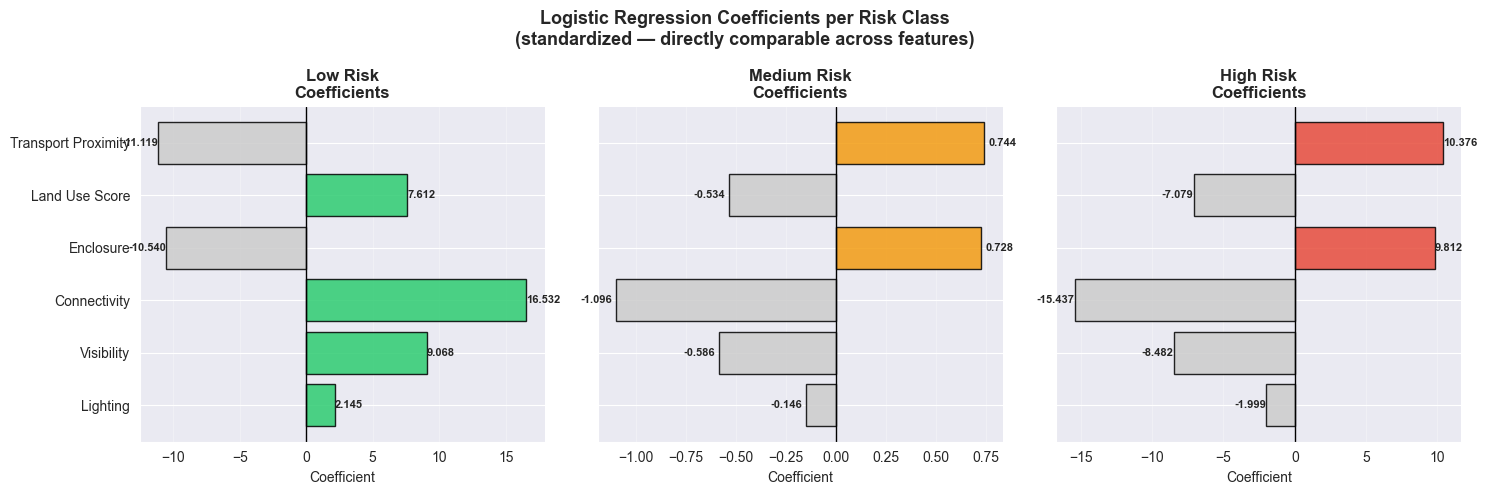

In [11]:
# Visualize coefficients
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, risk_class in zip(axes, RISK_ORDER):
    coeffs = coef_df.loc[risk_class]
    colors = [RISK_COLORS[risk_class] if v > 0 else '#cccccc' for v in coeffs]
    bars = ax.barh(coeffs.index, coeffs.values, color=colors, edgecolor='black', alpha=0.85)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'{risk_class.capitalize()} Risk\nCoefficients', fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient', fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, val in zip(bars, coeffs.values):
        x = val + 0.02 if val >= 0 else val - 0.02
        ha = 'left' if val >= 0 else 'right'
        ax.text(x, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
                va='center', ha=ha, fontsize=8, fontweight='bold')

plt.suptitle('Logistic Regression Coefficients per Risk Class\n(standardized — directly comparable across features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Random Forest

Random Forest as a benchmark — typically more accurate, and provides feature importances (how much each feature contributes to classification decisions overall).

In [17]:
rf = RandomForestClassifier(
    n_estimators=5,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest accuracy: {acc_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=RISK_ORDER))

Random Forest accuracy: 0.9641

              precision    recall  f1-score   support

         low       0.96      0.95      0.95      1459
      medium       0.98      0.97      0.97      2433
        high       0.96      0.96      0.96      3304

    accuracy                           0.96      7196
   macro avg       0.96      0.96      0.96      7196
weighted avg       0.96      0.96      0.96      7196



In [18]:
cv_scores_rf = cross_val_score(rf, X_train_scaled, y_train, cv=cv, scoring='accuracy')
print(f'5-fold CV accuracy: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')

5-fold CV accuracy: 0.9489 ± 0.0033


### 4.1 Feature Importances

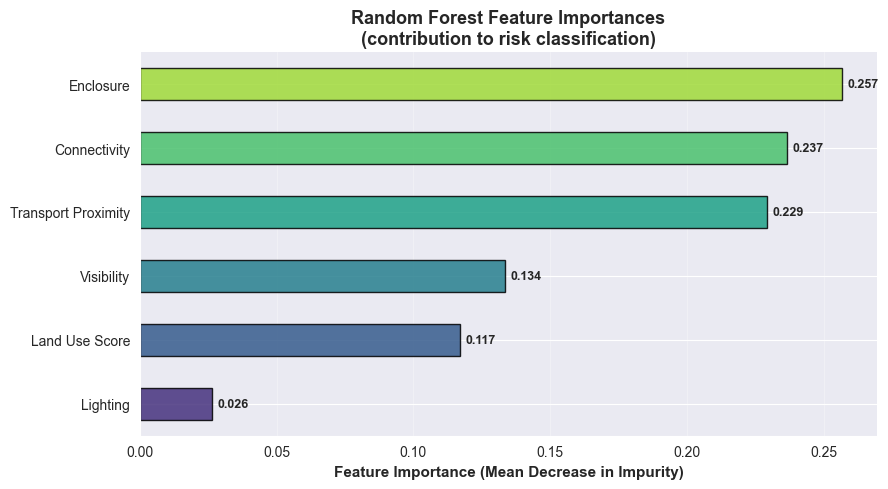

Feature importances (sorted):
  Enclosure                : 0.2567 (25.7%)
  Connectivity             : 0.2368 (23.7%)
  Transport Proximity      : 0.2292 (22.9%)
  Visibility               : 0.1337 (13.4%)
  Land Use Score           : 0.1171 (11.7%)
  Lighting                 : 0.0265 (2.6%)


In [19]:
importances = pd.Series(
    rf.feature_importances_,
    index=[clean_name(c) for c in FEATURE_COLS]
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('viridis', len(importances))
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='black', alpha=0.85)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11, fontweight='bold')
ax.set_title('Random Forest Feature Importances\n(contribution to risk classification)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
for i, (feat, val) in enumerate(importances.items()):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print('Feature importances (sorted):')
for feat, imp in importances.sort_values(ascending=False).items():
    print(f'  {feat:25s}: {imp:.4f} ({imp*100:.1f}%)')

## Step 5: Model Comparison

In [20]:
print('='*60)
print('MODEL COMPARISON')
print('='*60)
print(f'{"Model":<25} {"Test Acc":>10} {"CV Mean":>10} {"CV Std":>10}')
print('-'*60)
print(f'{"Logistic Regression":<25} {acc_lr:>10.4f} {cv_scores_lr.mean():>10.4f} {cv_scores_lr.std():>10.4f}')
print(f'{"Random Forest":<25} {acc_rf:>10.4f} {cv_scores_rf.mean():>10.4f} {cv_scores_rf.std():>10.4f}')
print()
print('Interpretation:')
print('  High accuracy on K-Means pseudo-labels means the model')
print('  closely reproduces the clustering decision boundary.')
print('  This enables transferable classification without re-clustering.')

MODEL COMPARISON
Model                       Test Acc    CV Mean     CV Std
------------------------------------------------------------
Logistic Regression           0.9985     0.9976     0.0006
Random Forest                 0.9641     0.9489     0.0033

Interpretation:
  High accuracy on K-Means pseudo-labels means the model
  closely reproduces the clustering decision boundary.
  This enables transferable classification without re-clustering.


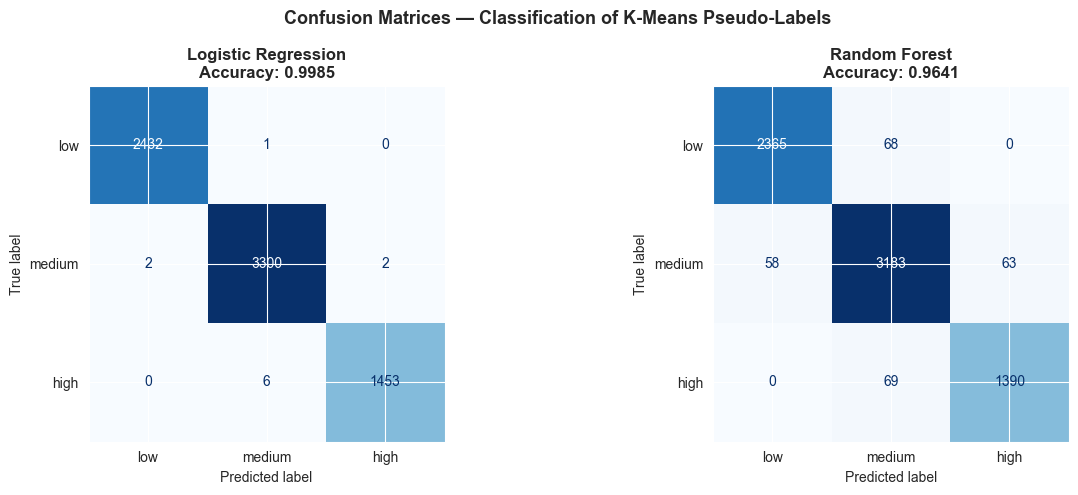

In [21]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred, labels=RISK_ORDER)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RISK_ORDER)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}',
                 fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — Classification of K-Means Pseudo-Labels',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Interpret the Classification Rule

The logistic regression equation for each class is:

$$\text{score}_{\text{class}} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_6 x_6$$

The predicted class is whichever has the highest score (softmax). Below we print the explicit formula.

In [22]:
print('='*70)
print('CLASSIFICATION FORMULA (Logistic Regression, standardized features)')
print('='*70)
print('Predicted class = argmax(score_low, score_medium, score_high)\n')

for cls, intercept in zip(lr.classes_, lr.intercept_):
    terms = [f'{intercept:+.4f}']
    for feat, coef in zip(FEATURE_COLS, lr.coef_[list(lr.classes_).index(cls)]):
        terms.append(f'{coef:+.4f} × {clean_name(feat)}')
    print(f'score_{cls} = ' + '\n           + '.join(terms))
    print()

print('Note: features must be standardized (mean=0, std=1) before applying.')
print('Scaler parameters saved alongside the model for new segment prediction.')

CLASSIFICATION FORMULA (Logistic Regression, standardized features)
Predicted class = argmax(score_low, score_medium, score_high)

score_high = -7.5506
           + -1.9988 × Lighting
           + -8.4823 × Visibility
           + -15.4365 × Connectivity
           + +9.8118 × Enclosure
           + -7.0787 × Land Use Score
           + +10.3756 × Transport Proximity

score_low = -2.5060
           + +2.1446 × Lighting
           + +9.0680 × Visibility
           + +16.5324 × Connectivity
           + -10.5402 × Enclosure
           + +7.6122 × Land Use Score
           + -11.1194 × Transport Proximity

score_medium = +10.0566
           + -0.1458 × Lighting
           + -0.5857 × Visibility
           + -1.0959 × Connectivity
           + +0.7283 × Enclosure
           + -0.5336 × Land Use Score
           + +0.7439 × Transport Proximity

Note: features must be standardized (mean=0, std=1) before applying.
Scaler parameters saved alongside the model for new segment prediction.


### 6.1 Which Features Are Most Decisive?

In [23]:
# Absolute coefficient magnitude across all classes = overall influence
overall_influence = coef_df.abs().mean(axis=0).sort_values(ascending=False)

print('Feature influence (mean |coefficient| across all classes):')
for feat, val in overall_influence.items():
    bar = '█' * int(val * 20)
    print(f'  {feat:25s}: {val:.4f}  {bar}')

print('\nTop features drive the low/medium/high boundary.')
print(f'Most decisive: {overall_influence.index[0]}')
print(f'Least decisive: {overall_influence.index[-1]}')

Feature influence (mean |coefficient| across all classes):
  Connectivity             : 11.0216  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Transport Proximity      : 7.4129  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Enclosure                : 7.0268  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Visibility               : 6.0453  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Land Use Score           : 5.0748  █████████████████████████████████████████████████████████████████████████████████████████████████████
  Lighting           

## Step 7: Export Model

In [24]:
model_dir = r'C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\models'
import os
os.makedirs(model_dir, exist_ok=True)

joblib.dump(lr,     os.path.join(model_dir, 'logistic_regression.pkl'))
joblib.dump(rf,     os.path.join(model_dir, 'random_forest.pkl'))
joblib.dump(scaler, os.path.join(model_dir, 'scaler.pkl'))

print('✓ Saved:')
print(f'  {model_dir}/logistic_regression.pkl')
print(f'  {model_dir}/random_forest.pkl')
print(f'  {model_dir}/scaler.pkl')
print()
print('To classify new segments:')
print('  scaler = joblib.load("scaler.pkl")')
print('  lr     = joblib.load("logistic_regression.pkl")')
print('  y_pred = lr.predict(scaler.transform(X_new))')

✓ Saved:
  C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\models/logistic_regression.pkl
  C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\models/random_forest.pkl
  C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\models/scaler.pkl

To classify new segments:
  scaler = joblib.load("scaler.pkl")
  lr     = joblib.load("logistic_regression.pkl")
  y_pred = lr.predict(scaler.transform(X_new))


## Summary

| Step | Details |
|------|---------|
| Input labels | K-Means pseudo-labels (low / medium / high) from `04_KMeans.ipynb` |
| Features | 6 normalized spatial features, standardized |
| Models | Logistic Regression (interpretable) + Random Forest (benchmark) |
| Validation | 80/20 split + 5-fold cross-validation |
| Key output | Logistic coefficients = explicit classification formula |
| Transferability | Fitted model + scaler can classify new segments directly |

**Methodological note:** Accuracy here reflects how well the model reproduces K-Means cluster assignments — not ground-truth risk. The value of this step is interpretability and transferability, not predictive validity.